In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False
    print('ipywidgets not available - interactive cells show static figures')

print('numpy', np.__version__, '| widgets:', HAS_WIDGETS)
rng = np.random.default_rng(0)

# ---------- helpers used in the whole lecture ----------
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def tanh(z):
    return np.tanh(z)

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    E = np.exp(Z)
    return E / E.sum(axis=1, keepdims=True)

def plot_boundary(ax, X, y, predict_fn, grid=150, title=''):
    x1 = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, grid)
    x2 = np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, grid)
    G1, G2 = np.meshgrid(x1, x2)
    P = predict_fn(np.c_[G1.ravel(), G2.ravel()]).reshape(G1.shape)
    ax.contourf(G1, G2, P, levels=20, cmap='coolwarm', alpha=0.35)
    ax.contour(G1, G2, P, levels=[0.5], colors='k', linewidths=2)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', edgecolors='k', s=18, alpha=0.7, label='class 0')
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c='red', edgecolors='k', s=18, alpha=0.7, label='class 1')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_aspect('equal', adjustable='box')

# ---------- architecture diagrams (one per task) ----------
def draw_arch(ax, sizes, node_labels=None, layer_names=None, title='', fontsize=9):
    n_layers = len(sizes)
    xs = np.linspace(0, 2.2 * (n_layers - 1), n_layers)
    pos = []
    for x, n in zip(xs, sizes):
        ys = np.linspace(-(n - 1) / 2.0, (n - 1) / 2.0, n)[::-1] * 0.9
        pos.append([(x, y) for y in ys])
    for li in range(n_layers - 1):
        for (x0, y0) in pos[li]:
            for (x1, y1) in pos[li + 1]:
                ax.plot([x0, x1], [y0, y1], color='0.6', alpha=0.55, lw=1, zorder=1)
    for li, layer in enumerate(pos):
        for ni, (x, y) in enumerate(layer):
            ax.add_patch(plt.Circle((x, y), 0.32, fc='white', ec='k', lw=1.6, zorder=2))
            lab = ''
            if node_labels is not None and li < len(node_labels) and ni < len(node_labels[li]):
                lab = node_labels[li][ni]
            ax.text(x, y, lab, ha='center', va='center', fontsize=fontsize, zorder=3)
    y_bot = -(max(sizes) - 1) / 2.0 * 0.9 - 0.75
    if layer_names:
        for x, nm in zip(xs, layer_names):
            ax.text(x, y_bot, nm, ha='center', va='top', fontsize=9)
    ax.set_xlim(-0.7, xs[-1] + 0.7)
    ax.set_ylim(y_bot - 0.5, -y_bot + 0.3)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(title)

# ---------- datasets ----------
# 1) linearly separable blobs
X_lin = np.vstack([rng.normal([-2, -2], 0.9, size=(150, 2)), rng.normal([2, 2], 0.9, size=(150, 2))])
y_lin = np.array([0] * 150 + [1] * 150)

# 2) XOR: 4 corners with jitter
corners = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
X_xor = np.vstack([c + rng.normal(0, 0.07, size=(75, 2)) for c in corners])
y_xor = np.repeat([0, 1, 1, 0], 75)

# 3) two moons
def make_moons(n=300, noise=0.12):
    n2 = n // 2
    t = np.linspace(0, np.pi, n2)
    outer = np.c_[np.cos(t), np.sin(t)]
    inner = np.c_[1 - np.cos(t), 0.5 - np.sin(t)]
    X = np.vstack([outer, inner]) + rng.normal(0, noise, size=(n, 2))
    y = np.array([0] * n2 + [1] * n2)
    return X, y
X_moon, y_moon = make_moons()

# 4) circles: ring vs center
def make_circles(n=300, noise=0.12):
    n2 = n // 2
    r0 = rng.uniform(0, 0.9, n2); a0 = rng.uniform(0, 2 * np.pi, n2)
    inner = np.c_[r0 * np.cos(a0), r0 * np.sin(a0)]
    a1 = rng.uniform(0, 2 * np.pi, n2)
    outer = np.c_[2.5 * np.cos(a1), 2.5 * np.sin(a1)] + rng.normal(0, noise, size=(n2, 2))
    X = np.vstack([inner, outer])
    y = np.array([0] * n2 + [1] * n2)
    return X, y
X_circ, y_circ = make_circles()

# 5) three blobs for multiclass
X_3 = np.vstack([rng.normal(c, 0.7, size=(100, 2)) for c in [(-2, -2), (2, -2), (0, 2.5)]])
y_3 = np.repeat([0, 1, 2], 100)

# 6) wavy 1D regression
X_reg = rng.uniform(-6, 6, size=(250, 1))
y_reg = 2 * np.sin(X_reg[:, 0]) + 0.15 * X_reg[:, 0] + rng.normal(0, 0.5, size=250)

print('shapes:', X_lin.shape, X_xor.shape, X_moon.shape, X_circ.shape, X_3.shape, X_reg.shape)

numpy 1.21.2 | widgets: True
shapes: (300, 2) (300, 2) (300, 2) (300, 2) (300, 2) (250, 1)


# Лекция 3: Multilayer Perceptron (MLP)

**План:**
1. Почему одного слоя мало 2. XOR problem 3. Зачем нужны activations между слоями
4. Сложные classification boundaries 5. Сложные regression functions 6. Log-likelihood loss
7. Multiclass + cross-entropy 8. Chain rule 9. Backprop на 2 входах 10. Backprop в матрицах

**Обозначения на всю лекцию:** вход $x \in \mathbb{R}^2$, один нейрон вычисляет
$z = w_1 x_1 + w_2 x_2 + b$, $\;\hat{y} = \phi(z)$ с activation $\phi$.
MLP просто складывает такие нейроны в **layers** (слои).

## 1. Почему один персептрон — это мало

Один нейрон рисует **одну прямую линию** $w_1 x_1 + w_2 x_2 + b = 0$.
Всё с одной стороны — class 0, с другой — class 1.

- Слева: blobs делятся одной линией — один нейрон идеален.
- Центр/справа: moons и circles — **никакая прямая** не делит цвета.
  Как линию ни крути, много точек останется не с той стороны.

Поэтому one-layer perceptron умеет только **linearly separable** задачи.

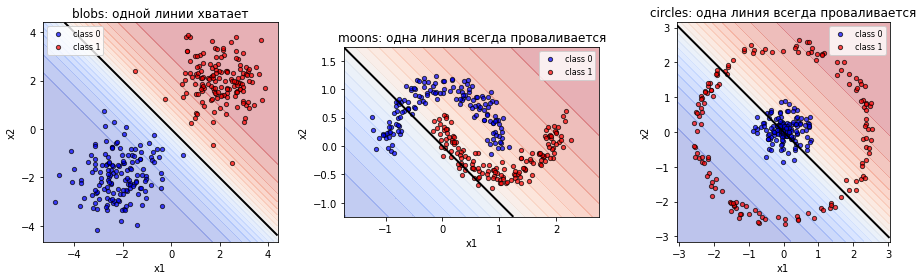

In [2]:
# FIGURE: one straight line is all a single neuron has. Works for blobs, fails for moons/circles.
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
# a reasonable hand-picked line for blobs
w, b = np.array([1.0, 1.0]), 0.0
for ax, X, y, t in zip(axes, [X_lin, X_moon, X_circ], [y_lin, y_moon, y_circ],
                       ['blobs: одной линии хватает', 'moons: одна линия всегда проваливается', 'circles: одна линия всегда проваливается']):
    plot_boundary(ax, X, y, lambda G, w=w, b=b: sigmoid(G @ w + b), title=t)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.tight_layout(); plt.show()

In [3]:
# INTERACTIVE: drag w1, w2, b and try to separate the moons with ONE line. You will fail - that is the point.
def try_line(w1=1.0, w2=-0.5, b=0.2):
    fig, ax = plt.subplots(figsize=(5.5, 5))
    plot_boundary(ax, X_moon, y_moon, lambda G: sigmoid(G @ np.array([w1, w2]) + b),
                  title=f'w1={w1:.2f} w2={w2:.2f} b={b:.2f} — всё равно одна прямая')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    plt.tight_layout(); plt.show()

if HAS_WIDGETS:
    widgets.interact(try_line,
        w1=widgets.FloatSlider(value=1.0, min=-3, max=3, step=0.1, description='w1'),
        w2=widgets.FloatSlider(value=-0.5, min=-3, max=3, step=0.1, description='w2'),
        b=widgets.FloatSlider(value=0.2, min=-3, max=3, step=0.1, description='b'))
else:
    try_line()

interactive(children=(FloatSlider(value=1.0, description='w1', max=3.0, min=-3.0), FloatSlider(value=-0.5, des…

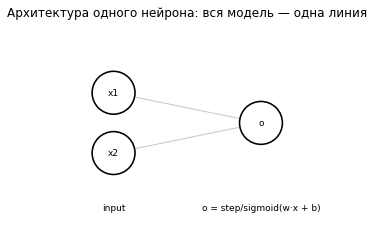

In [4]:
# ARCHITECTURE: a single neuron - 2 inputs, 1 output, one line.
fig, ax = plt.subplots(figsize=(6, 3.5))
draw_arch(ax, [2, 1],
          node_labels=[['x1', 'x2'], ['o']],
          layer_names=['input', 'o = step/sigmoid(w·x + b)'],
          title='Архитектура одного нейрона: вся модель — одна линия')
plt.tight_layout(); plt.show()

## 2. XOR problem

Таблица истинности XOR: $(0,0)\to 0$, $(1,1)\to 0$, $(0,1)\to 1$, $(1,0)\to 1$.
Посмотрите на график: красные точки — на одной диагонали, синие — на другой.
**Никакая прямая** не положит две красные точки с одной стороны, а две синие — с другой.

Минский и Пейперт (1969) показали ровно это — и neural networks замерли на годы.

Фикс: взять **две линии** (два hidden neurons), потом их скомбинировать:
- средний график: выход MLP чисто делит четыре угла;
- правый график: прогоним каждую точку через hidden layer $(x_1,x_2) \to (h_1,h_2)$.
  В новом hidden space четыре угла **уже** linearly separable!

То есть hidden layer **переписывает данные** в пространство, где одной линии хватает.

скрытые координаты (0,0),(0,1),(1,0),(1,1):
[[0.007 1.   ]
 [0.993 0.993]
 [0.993 0.993]
 [1.    0.007]]
выходы: [0.007 0.992 0.992 0.007] (надо 0,1,1,0)


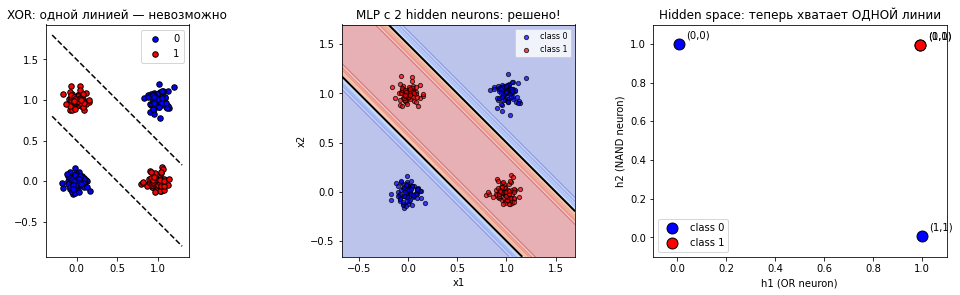

In [5]:
# FIGURE: XOR is impossible with 1 line; 2 hidden neurons rewrite the space so 1 line suffices.
# hand-crafted solution: h1 = OR-neuron, h2 = NAND-neuron (sigmoid with big weights ~ step)
def xor_hidden(X):
    h1 = sigmoid(10 * (X[:, 0] + X[:, 1] - 0.5))
    h2 = sigmoid(10 * (-X[:, 0] - X[:, 1] + 1.5))
    return np.c_[h1, h2]

def xor_out(X):
    H = xor_hidden(X)
    return sigmoid(10 * (H[:, 0] + H[:, 1] - 1.5))

X4 = corners  # clean truth-table corners
H4 = xor_hidden(X4)
print('скрытые координаты (0,0),(0,1),(1,0),(1,1):')
print(np.round(H4, 3))
print('выходы:', np.round(xor_out(X4), 3), '(надо 0,1,1,0)')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
ax = axes[0]
ax.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], c='blue', edgecolors='k', s=30, label='0')
ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c='red', edgecolors='k', s=30, label='1')
xs = np.linspace(-0.3, 1.3, 50)
ax.plot(xs, 0.5 - xs, 'k--', lw=1.5); ax.plot(xs, 1.5 - xs, 'k--', lw=1.5)
ax.set_title('XOR: одной линией — невозможно'); ax.legend(); ax.set_aspect('equal', adjustable='box')
ax = axes[1]
plot_boundary(ax, X_xor, y_xor, xor_out, title='MLP с 2 hidden neurons: решено!')
ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax = axes[2]
ax.scatter(H4[[0, 3], 0], H4[[0, 3], 1], c='blue', edgecolors='k', s=120, label='class 0')
ax.scatter(H4[[1, 2], 0], H4[[1, 2], 1], c='red', edgecolors='k', s=120, label='class 1')
for (xh, yh), lab in zip(H4, ['(0,0)', '(0,1)', '(1,0)', '(1,1)']):
    ax.text(xh + 0.03, yh + 0.03, lab)
ax.set_xlim(-0.1, 1.1); ax.set_ylim(-0.1, 1.1)
ax.set_xlabel('h1 (OR neuron)'); ax.set_ylabel('h2 (NAND neuron)')
ax.set_title('Hidden space: теперь хватает ОДНОЙ линии'); ax.legend()
plt.tight_layout(); plt.show()

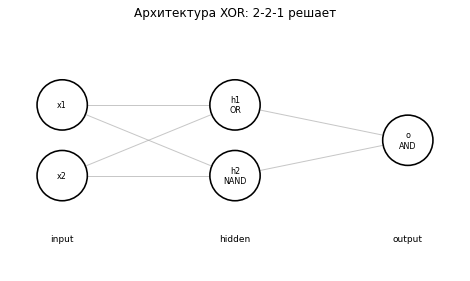

In [6]:
# ARCHITECTURE: the XOR net 2-2-1 with roles of every neuron.
fig, ax = plt.subplots(figsize=(7, 4))
draw_arch(ax, [2, 2, 1],
          node_labels=[['x1', 'x2'], ['h1\nOR', 'h2\nNAND'], ['o\nAND']],
          layer_names=['input', 'hidden', 'output'],
          title='Архитектура XOR: 2-2-1 решает', fontsize=8)
plt.tight_layout(); plt.show()

## 3. Зачем нужны activations между слоями

Без activations два слоя **схлопываются в один**:

$$W_2 (W_1 x + b_1) + b_2 = \underbrace{(W_2 W_1)}_{W_{eff}} x + \underbrace{(W_2 b_1 + b_2)}_{b_{eff}}$$

Всё равно одна прямая — depth ничего не дал (слева: границы совпадают).

А activation $\phi$ (справа: ReLU, sigmoid, tanh) **изгибает** пространство после каждого слоя:
нет изгиба — нет новой мощности. Правило: **linear layers смешивают, activations изгибают**.

W_eff: [ 0.048 -0.024] b_eff: 0.744


/tmp/ipykernel_31529/670921279.py:36: UserWarning: No contour levels were found within the data range.
  ax.contour(G1, G2, P, levels=[0.5], colors='k', linewidths=2)


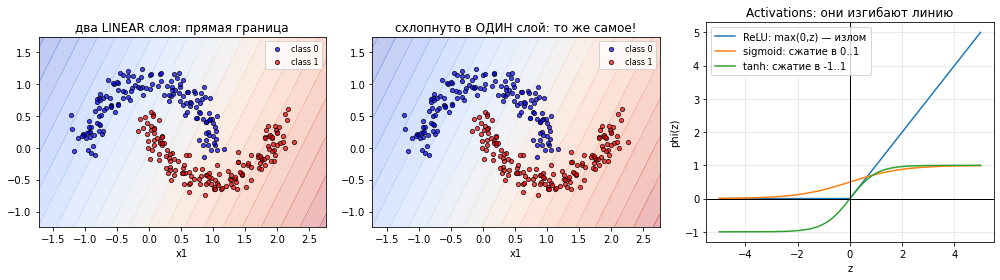

In [7]:
# FIGURE: left - two linear layers == one linear layer (same straight boundary). Right - activation gallery.
r = np.random.default_rng(7)
W1 = r.normal(size=(2, 3)); b1 = r.normal(size=3)
W2 = r.normal(size=(3, 1)); b2 = 0.3
W_eff = W1 @ W2  # (2,3) @ (3,1) -> (2,1); b_eff scalar
b_eff = float(b1 @ W2 + b2)
print('W_eff:', np.round(W_eff.ravel(), 3), 'b_eff:', round(b_eff, 3))

def p_two(G):
    return sigmoid((G @ W1 + b1) @ W2 + b2).ravel()

def p_one(G):
    return sigmoid(G @ W_eff.ravel() + b_eff)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
plot_boundary(axes[0], X_moon, y_moon, p_two, title='два LINEAR слоя: прямая граница')
plot_boundary(axes[1], X_moon, y_moon, p_one, title='схлопнуто в ОДИН слой: то же самое!')
axes[0].set_xlabel('x1'); axes[1].set_xlabel('x1')
ax = axes[2]
z = np.linspace(-5, 5, 400)
ax.plot(z, relu(z), label='ReLU: max(0,z) — излом')
ax.plot(z, sigmoid(z), label='sigmoid: сжатие в 0..1')
ax.plot(z, tanh(z), label='tanh: сжатие в -1..1')
ax.axhline(0, color='k', lw=1); ax.axvline(0, color='k', lw=1)
ax.set_title('Activations: они изгибают линию'); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlabel('z'); ax.set_ylabel('phi(z)')
plt.tight_layout(); plt.show()

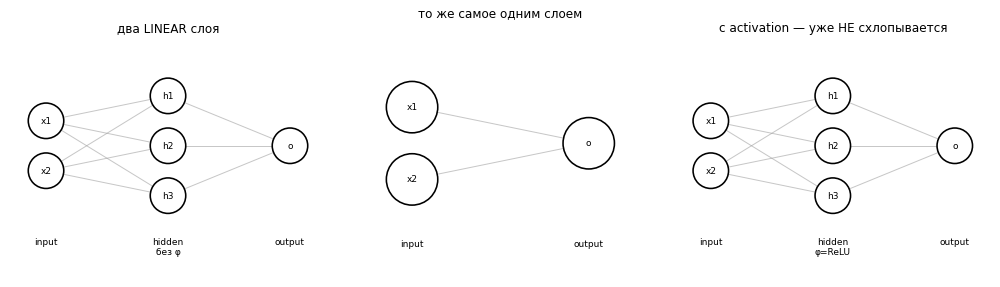

In [8]:
# ARCHITECTURE: linear stacks collapse, activations save depth.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
draw_arch(axes[0], [2, 3, 1], node_labels=[['x1', 'x2'], ['h1', 'h2', 'h3'], ['o']],
          layer_names=['input', 'hidden\nбез φ', 'output'],
          title='два LINEAR слоя')
draw_arch(axes[1], [2, 1], node_labels=[['x1', 'x2'], ['o']],
          layer_names=['input', 'output'],
          title='то же самое одним слоем')
draw_arch(axes[2], [2, 3, 1], node_labels=[['x1', 'x2'], ['h1', 'h2', 'h3'], ['o']],
          layer_names=['input', 'hidden\nφ=ReLU', 'output'],
          title='с activation — уже НЕ схлопывается')
plt.tight_layout(); plt.show()

## 4. MLP рисует сложные classification boundaries

Идея одной картинкой: каждый hidden neuron рисует **свою линию**; output neuron **голосует** между ними.
С 2 hidden neurons получается полоска; с 8–16 голоса обводят moons, кольца, спирали.

Ниже: один и тот же training code, меняется только размер hidden layer $H$.
$H=2$ underfits (всё ещё слишком прямо), $H=16$ обнимает circles. Loss падает вместе с заострением границы.
(Этот training использует backprop — чёрный ящик, который откроем в разделах 9–10.)

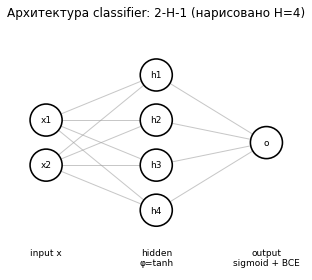

In [9]:
# ARCHITECTURE: binary classifier 2-H-1 (drawn with H=4).
fig, ax = plt.subplots(figsize=(7, 4))
draw_arch(ax, [2, 4, 1],
          node_labels=[['x1', 'x2'], ['h1', 'h2', 'h3', 'h4'], ['o']],
          layer_names=['input x', 'hidden\nφ=tanh', 'output\nsigmoid + BCE'],
          title='Архитектура classifier: 2-H-1 (нарисовано H=4)')
plt.tight_layout(); plt.show()

H=2:  final loss 0.260 | acc 0.90
H=16: final loss 0.002 | acc 1.00


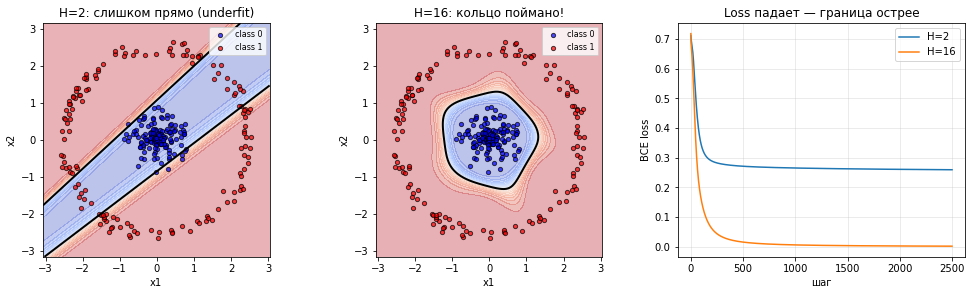

In [10]:
# Train a 2-H-1 MLP (tanh hidden + sigmoid out, BCE loss) with plain full-batch gradient descent.
def train_bce_mlp(X, y, H=8, lr=0.5, iters=2500, seed=1):
    r = np.random.default_rng(seed)
    N = X.shape[0]
    W1 = r.normal(0, 1, size=(2, H)) * np.sqrt(1 / 2)
    b1 = np.zeros(H)
    W2 = r.normal(0, 1, size=(H, 1)) * np.sqrt(1 / H)
    b2 = np.zeros(1)
    hist = []
    for _ in range(iters):
        A1 = tanh(X @ W1 + b1)
        A2 = sigmoid(A1 @ W2 + b2)
        eps = 1e-9
        loss = -np.mean(y.reshape(-1, 1) * np.log(A2 + eps) + (1 - y.reshape(-1, 1)) * np.log(1 - A2 + eps))
        hist.append(loss)
        dZ2 = (A2 - y.reshape(-1, 1)) / N   # backprop (derived in sections 9-10)
        dW2 = A1.T @ dZ2; db2 = dZ2.sum(axis=0)
        dZ1 = (dZ2 @ W2.T) * (1 - A1 ** 2)
        dW1 = X.T @ dZ1; db1 = dZ1.sum(axis=0)
        W2 -= lr * dW2; b2 -= lr * db2; W1 -= lr * dW1; b1 -= lr * db1
    return (W1, b1, W2, b2), np.array(hist)

def mlp_prob(X, params):
    W1, b1, W2, b2 = params
    return sigmoid(tanh(X @ W1 + b1) @ W2 + b2).ravel()

p2, h2 = train_bce_mlp(X_circ, y_circ, H=2, lr=0.5, iters=2500, seed=1)
p16, h16 = train_bce_mlp(X_circ, y_circ, H=16, lr=0.5, iters=2500, seed=1)
print(f'H=2:  final loss {h2[-1]:.3f} | acc {((mlp_prob(X_circ, p2) > 0.5) == y_circ).mean():.2f}')
print(f'H=16: final loss {h16[-1]:.3f} | acc {((mlp_prob(X_circ, p16) > 0.5) == y_circ).mean():.2f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
plot_boundary(axes[0], X_circ, y_circ, lambda G: mlp_prob(G, p2), title='H=2: слишком прямо (underfit)')
plot_boundary(axes[1], X_circ, y_circ, lambda G: mlp_prob(G, p16), title='H=16: кольцо поймано!')
axes[2].plot(h2, label='H=2'); axes[2].plot(h16, label='H=16')
axes[2].set_xlabel('шаг'); axes[2].set_ylabel('BCE loss'); axes[2].set_title('Loss падает — граница острее')
axes[2].legend(); axes[2].grid(True, alpha=0.3)
for ax in axes[:2]:
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
plt.tight_layout(); plt.show()

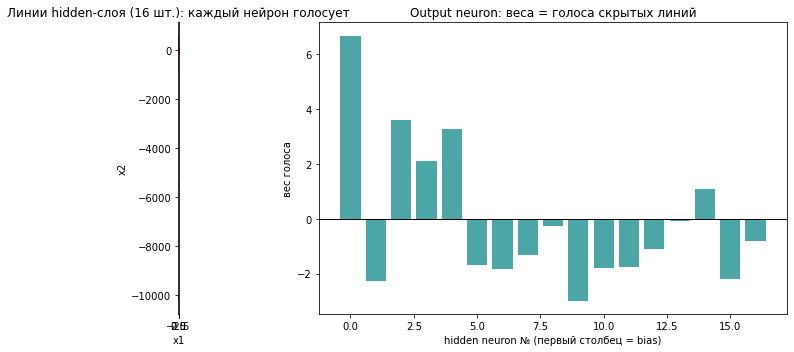

In [11]:
# FIGURE: each hidden neuron is one line; the output mixes their votes into a ring.
W1, b1, W2, b2 = p16
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.scatter(X_circ[y_circ == 0, 0], X_circ[y_circ == 0, 1], c='blue', alpha=0.4, s=15)
ax.scatter(X_circ[y_circ == 1, 0], X_circ[y_circ == 1, 1], c='red', alpha=0.4, s=15)
xs = np.linspace(-4, 4, 100)
for j in range(W1.shape[1]):
    if abs(W1[1, j]) > 1e-6:
        ax.plot(xs, -(b1[j] + W1[0, j] * xs) / W1[1, j], lw=1, alpha=0.8)
ax.set_title(f'Линии hidden-слоя ({W1.shape[1]} шт.): каждый нейрон голосует')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.set_aspect('equal', adjustable='box')
ax = axes[1]
ax.bar(range(len(b2) + len(W2)), list(np.atleast_1d(b2)) + list(W2.ravel()), color='teal', alpha=0.7)
ax.axhline(0, color='k', lw=1)
ax.set_title('Output neuron: веса = голоса скрытых линий')
ax.set_xlabel('hidden neuron № (первый столбец = bias)'); ax.set_ylabel('вес голоса')
plt.tight_layout(); plt.show()

## 5. MLP описывает сложные regression functions

Тот же трюк в 1D: прямая не ляжет на волну.
Дадим hidden layer ReLU hinges $\max(0, w x + b)$ — каждый нейрон один излом.
Сумма изломов даёт кусочно-линейную кривую, которая обнимет любую форму:
2 нейрона = ломаная, 20 нейронов = почти гладкая волна.

Правый график открывает обученную сеть: тонкие серые hinges, толстая синяя = их сумма.

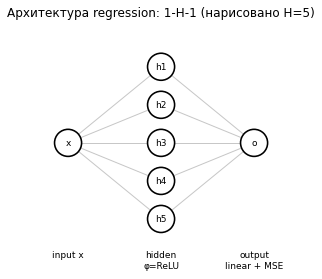

In [12]:
# ARCHITECTURE: regressor 1-H-1 (drawn with H=5).
fig, ax = plt.subplots(figsize=(7, 4))
draw_arch(ax, [1, 5, 1],
          node_labels=[['x'], ['h1', 'h2', 'h3', 'h4', 'h5'], ['o']],
          layer_names=['input x', 'hidden\nφ=ReLU', 'output\nlinear + MSE'],
          title='Архитектура regression: 1-H-1 (нарисовано H=5)')
plt.tight_layout(); plt.show()

H=2:  MSE 1.857
H=20: MSE 0.318


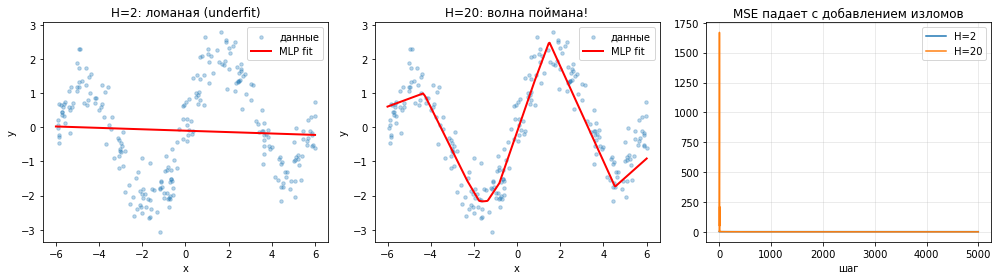

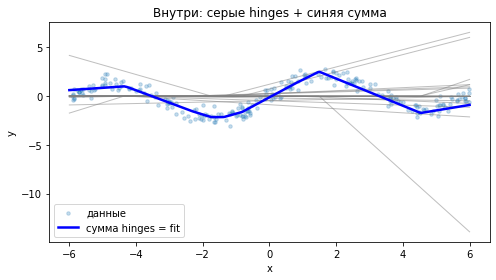

In [13]:
# 1-H-1 MLP with ReLU hidden + linear output, MSE loss, full-batch GD.
def train_reg_mlp(x, y, H=16, lr=0.01, iters=5000, seed=2):
    r = np.random.default_rng(seed)
    N = x.shape[0]
    W1 = r.normal(0, 1, size=(1, H))
    b1 = np.linspace(-np.abs(x).max(), np.abs(x).max(), H) + r.normal(0, 0.3, size=H)
    W2 = r.normal(0, 1, size=(H, 1)) * 0.1
    b2 = np.array([0.0])
    hist = []
    for _ in range(iters):
        Z1 = x @ W1 + b1
        A1 = relu(Z1)
        P = (A1 @ W2 + b2)[:, 0]
        e = P - y
        hist.append(np.mean(e ** 2))
        dP = (2 / N) * e.reshape(-1, 1)
        dW2 = A1.T @ dP; db2 = dP.sum(axis=0)
        dZ1 = (dP @ W2.T) * (Z1 > 0)
        dW1 = x.T @ dZ1; db1 = dZ1.sum(axis=0)
        W2 -= lr * dW2; b2 -= lr * db2; W1 -= lr * dW1; b1 -= lr * db1
    return (W1, b1, W2, b2), np.array(hist)

def reg_pred(x, params):
    W1, b1, W2, b2 = params
    return (relu(x @ W1 + b1) @ W2 + b2)[:, 0]

xs = np.linspace(-6, 6, 300).reshape(-1, 1)
pr2, hr2 = train_reg_mlp(X_reg, y_reg, H=2, lr=0.01, iters=5000, seed=2)
pr20, hr20 = train_reg_mlp(X_reg, y_reg, H=20, lr=0.01, iters=5000, seed=2)
print(f'H=2:  MSE {hr2[-1]:.3f}')
print(f'H=20: MSE {hr20[-1]:.3f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, pr, t in zip(axes[:2], [pr2, pr20], ['H=2: ломаная (underfit)', 'H=20: волна поймана!']):
    ax.scatter(X_reg[:, 0], y_reg, alpha=0.3, s=12, label='данные')
    ax.plot(xs[:, 0], reg_pred(xs, pr), 'r-', lw=2, label='MLP fit')
    ax.set_title(t); ax.legend(); ax.set_xlabel('x'); ax.set_ylabel('y')
axes[2].plot(hr2, label='H=2'); axes[2].plot(hr20, label='H=20')
axes[2].set_title('MSE падает с добавлением изломов'); axes[2].set_xlabel('шаг'); axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# open the H=20 net: every hidden ReLU hinge + their sum
W1, b1, W2, b2 = pr20
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(X_reg[:, 0], y_reg, alpha=0.25, s=12, label='данные')
for j in range(W1.shape[1]):
    ax.plot(xs[:, 0], (relu(xs @ W1[:, [j]] + b1[j]) * W2[j, 0]).ravel(), color='gray', lw=1, alpha=0.5)
ax.plot(xs[:, 0], reg_pred(xs, pr20), 'b-', lw=2.5, label='сумма hinges = fit')
ax.set_title('Внутри: серые hinges + синяя сумма'); ax.legend()
ax.set_xlabel('x'); ax.set_ylabel('y')
plt.tight_layout(); plt.show()

## 6. Log-likelihood loss (бинарный случай)

Для classification выход $p = \sigma(z)$ — это **вероятность** class 1.
Одна точка — подбрасывание монетки: $P(y|p) = p^y (1-p)^{1-y}$.
Независимые точки перемножаются, $\log$ превращает $\prod$ в $\sum$:

$$\log L = \sum_i \big( y_i \log p_i + (1-y_i)\log(1-p_i) \big), \qquad J_{BCE} = -\frac{1}{n}\log L$$

Минимум $J_{BCE}$ = максимум likelihood.

**Откуда вообще берётся likelihood? Принцип maximum likelihood (MLE):**
1. Модель с параметрами θ каждому исходу приписывает вероятность $P(данные|θ)$.
2. Likelihood $L(θ) = P(данные|θ)$ — «насколько правдоподобны наши данные при таких параметрах».
3. Выбираем θ с максимальным $L$ — модель, при которой увиденное наиболее вероятно.
4. $\log$ не меняет победителя (монотонна), но превращает $\prod$ в $\sum$: числа не схлопываются в ноль, а сумма считается легко.
5. Поэтому минимизируем negative log-likelihood: $J = -\frac{1}{n}\log L$.

Интуиция из information theory: $-\log p$ — это «удивление» (surprise) в nats. Предсказал $p=0.9$ и угадал — удивление $0.1$; предсказал $p=0.1$ и облажался — удивление $2.3$. Loss = среднее удивление. Хорошая модель удивляется редко.

**Связь с Lecture 2:** там шум был Gaussian → MLE дала MSE. Здесь исходы — Bernoulli (монетка) → MLE даёт BCE. Два noise models — два losses:
- regression: $y = \hat y + \varepsilon$, $\varepsilon \sim \mathcal{N}$ → MSE;
- classification: $y \sim Bernoulli(p)$ → BCE.

Картинки:
- BCE-кривые: уверен + прав $\to$ loss $\approx 0$; уверен + неправ $\to$ огромный loss;
- монетка 7/10: likelihood максимален ровно при $p=0.7$ — MLE «угадывает» частоту;
- для точки с меткой 1 у BCE везде здоровый наклон, а у MSE+sigmoid — **плоско** (градиенту не за что зацепиться). Поэтому для classification берут BCE, а не MSE.

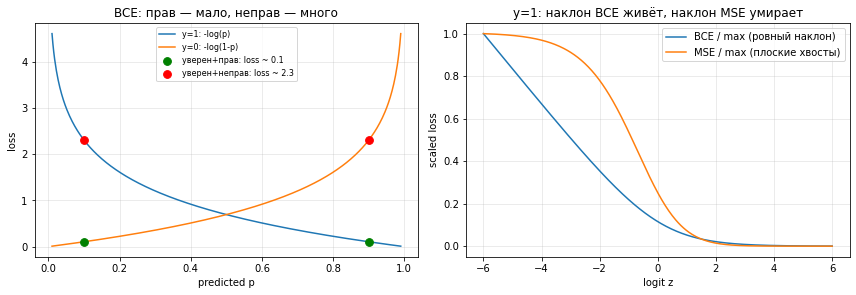

loss уверен+прав: 0.11 | уверен+неправ: 2.30


In [14]:
# FIGURE: BCE loss curves + why BCE beats MSE for classification (gradient never dies).
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
p = np.linspace(0.01, 0.99, 400)
ax.plot(p, -np.log(p), label='y=1: -log(p)')
ax.plot(p, -np.log(1 - p), label='y=0: -log(1-p)')
ax.scatter([0.9, 0.1], [-np.log(0.9), -np.log(0.9)], c='green', s=60, zorder=5, label='уверен+прав: loss ~ 0.1')
ax.scatter([0.1, 0.9], [-np.log(0.1), -np.log(0.1)], c='red', s=60, zorder=5, label='уверен+неправ: loss ~ 2.3')
ax.set_title('BCE: прав — мало, неправ — много')
ax.set_xlabel('predicted p'); ax.set_ylabel('loss'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax = axes[1]
z = np.linspace(-6, 6, 400); p = sigmoid(z)
bce = -(np.log(p) + 0)  # y = 1
mse = (p - 1) ** 2
ax.plot(z, bce / bce.max(), label='BCE / max (ровный наклон)')
ax.plot(z, mse / mse.max(), label='MSE / max (плоские хвосты)')
ax.set_title('y=1: наклон BCE живёт, наклон MSE умирает')
ax.set_xlabel('logit z'); ax.set_ylabel('scaled loss'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print('loss уверен+прав: %.2f | уверен+неправ: %.2f' % (-np.log(0.9), -np.log(0.1)))

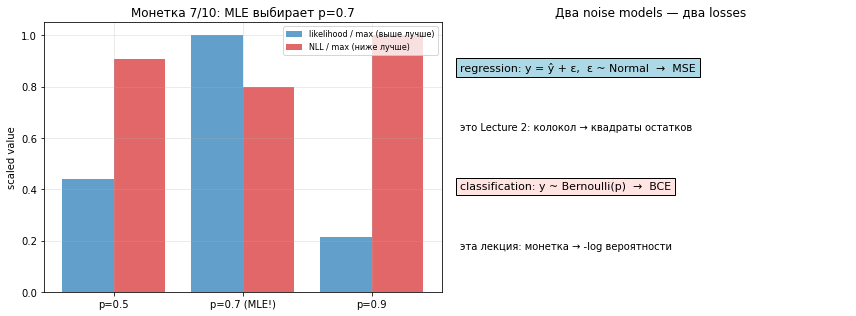

L(p=0.5)=0.0010 L(p=0.7)=0.0022 L(p=0.9)=0.0005 -> максимум при p=0.7


In [15]:
# FIGURE: MLE in action on a coin (7 heads of 10) + two noise models -> two losses.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
cand = np.array([0.5, 0.7, 0.9])
L = cand ** 7 * (1 - cand) ** 3
nll = -np.log(L)
x = np.arange(len(cand))
ax.bar(x, L / L.max(), width=0.4, label='likelihood / max (выше лучше)', color='tab:blue', alpha=0.7)
ax.bar(x + 0.4, nll / nll.max(), width=0.4, label='NLL / max (ниже лучше)', color='tab:red', alpha=0.7)
ax.set_xticks(x + 0.2); ax.set_xticklabels(['p=0.5', 'p=0.7 (MLE!)', 'p=0.9'])
ax.set_title('Монетка 7/10: MLE выбирает p=0.7'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
ax.set_ylabel('scaled value')
ax = axes[1]; ax.axis('off')
ax.set_title('Два noise models — два losses')
ax.text(0.02, 0.82, 'regression: y = ŷ + ε,  ε ~ Normal  →  MSE', fontsize=11,
        bbox=dict(fc='lightblue', ec='k'), transform=ax.transAxes)
ax.text(0.02, 0.60, 'это Lecture 2: колокол → квадраты остатков', fontsize=10, transform=ax.transAxes)
ax.text(0.02, 0.38, 'classification: y ~ Bernoulli(p)  →  BCE', fontsize=11,
        bbox=dict(fc='mistyrose', ec='k'), transform=ax.transAxes)
ax.text(0.02, 0.16, 'эта лекция: монетка → -log вероятности', fontsize=10, transform=ax.transAxes)
plt.tight_layout(); plt.show()
print('L(p=0.5)=%.4f L(p=0.7)=%.4f L(p=0.9)=%.4f -> максимум при p=0.7' % tuple(L))

### Производная BCE + sigmoid: откуда берётся $p - y$

Loss одного примера: $J = -[y \log p + (1-y)\log(1-p)]$, $p = \sigma(z) = 1/(1+e^{-z})$.
Chain rule в два звена: $\frac{dJ}{dz} = \frac{dJ}{dp}\cdot\frac{dp}{dz}$.

Шаг 1 — loss по вероятности (производные $\log$):
$$\frac{dJ}{dp} = -\frac{y}{p} + \frac{1-y}{1-p} = \frac{p - y}{p(1-p)}$$
(общий знаменатель: $-y(1-p) + p(1-y) = p - y$).

Шаг 2 — sigmoid по логиту:
$$\frac{dp}{dz} = \sigma(z)(1-\sigma(z)) = p(1-p).$$

Шаг 3 — перемножаем, всё сокращается:
$$\frac{dJ}{dz} = \frac{p-y}{p(1-p)}\cdot p(1-p) = p - y.$$

Наклон sigmoid ровно гасит кривизну loss — поэтому градиент такой чистый: **ошибка = предсказание минус правда**. Ниже: проверка числом и кривые градиента (нужен только chain rule из раздела 8).

y=1 z=0.3: p=0.574 | dJ/dp=-1.741 dp/dz=0.244 | product=-0.425557 p-y=-0.425557 numeric=-0.425557


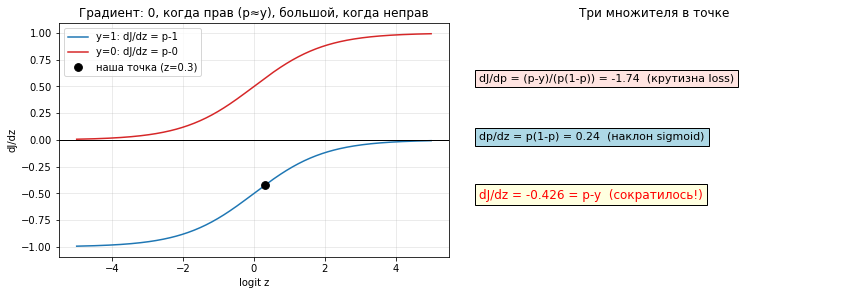

In [16]:
# FIGURE+PROOF: analytic factors vs numeric gradient; gradient curves for y=0/1.
y, z = 1, 0.3
p = sigmoid(z)
dJ_dp = (p - y) / (p * (1 - p))
dp_dz = p * (1 - p)
dJ_dz = dJ_dp * dp_dz
e = 1e-7
Jp = -(y * np.log(sigmoid(z + e)) + (1 - y) * np.log(1 - sigmoid(z + e)))
Jm = -(y * np.log(sigmoid(z - e)) + (1 - y) * np.log(1 - sigmoid(z - e)))
num = (Jp - Jm) / (2 * e)
print(f'y={y} z={z}: p={p:.3f} | dJ/dp={dJ_dp:.3f} dp/dz={dp_dz:.3f} | product={dJ_dz:.6f} p-y={p-y:.6f} numeric={num:.6f}')
assert np.isclose(dJ_dz, p - y) and np.isclose(dJ_dz, num)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
zz = np.linspace(-5, 5, 300)
for yy, c in [(1, 'tab:blue'), (0, 'tab:red')]:
    ax.plot(zz, sigmoid(zz) - yy, color=c, label=f'y={yy}: dJ/dz = p-{yy}')
ax.axhline(0, color='k', lw=1)
ax.scatter([z], [p - y], c='k', s=60, zorder=5, label=f'наша точка (z={z})')
ax.set_title('Градиент: 0, когда прав (p≈y), большой, когда неправ')
ax.set_xlabel('logit z'); ax.set_ylabel('dJ/dz'); ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[1]; ax.axis('off')
ax.set_title('Три множителя в точке')
ax.text(0.05, 0.75, f'dJ/dp = (p-y)/(p(1-p)) = {dJ_dp:.2f}  (крутизна loss)', fontsize=11,
        bbox=dict(fc='mistyrose', ec='k'), transform=ax.transAxes)
ax.text(0.05, 0.50, f'dp/dz = p(1-p) = {dp_dz:.2f}  (наклон sigmoid)', fontsize=11,
        bbox=dict(fc='lightblue', ec='k'), transform=ax.transAxes)
ax.text(0.05, 0.25, f'dJ/dz = {dJ_dz:.3f} = p-y  (сократилось!)', fontsize=12, color='red',
        bbox=dict(fc='lightyellow', ec='k'), transform=ax.transAxes)
plt.tight_layout(); plt.show()

## 7. Multiclass classification и cross-entropy

Трём классам нужны три score $z_1, z_2, z_3$. **Softmax** превращает их в вероятности:

$$p_k = \frac{e^{z_k}}{e^{z_1} + e^{z_2} + e^{z_3}}, \qquad \sum_k p_k = 1$$

Больше score $\to$ больше доля. Метки — **one-hot**, например class 1 = $(0,1,0)$.
Cross-entropy — та же log-likelihood идея, но классов больше:

$$J_{CE} = -\frac{1}{n}\sum_i \sum_{k} y_{ik} \log p_{ik} = -\frac{1}{n}\sum_i \log p_{i,\,true\,class}$$

Важен только true class: loss = $-\log$ вероятности, отданной правильному ответу.
Ниже: один вектор logits — столбиками вероятностей, и MLP, режущий три области.

**Вероятностная история.** Multiclass — это игральный кубик с $K$ гранями (categorical distribution).
Softmax задаёт «загруженность» кубика: $p_k$ — вероятность грани $k$.
One-hot метка — «кубик реально выпал гранью $k$»: эмпирическое распределение (вся масса на одной грани).
Cross-entropy $-\log p_{true}$ — удивление от реального исхода; средняя CE по batch — расстояние между предсказанным и истинным распределениями.
Точнее: $CE = H(data) + KL(data \Vert model)$; энтропия данных $H$ от модели не зависит, поэтому минимум CE = минимум KL = распределения совпали. Модель учится «быть тем же кубиком».

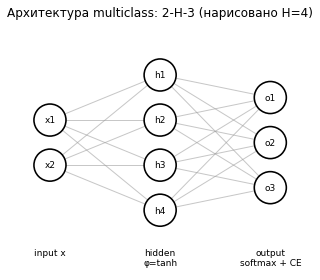

In [17]:
# ARCHITECTURE: multiclass net 2-H-3 with softmax output (drawn with H=4).
fig, ax = plt.subplots(figsize=(7, 4))
draw_arch(ax, [2, 4, 3],
          node_labels=[['x1', 'x2'], ['h1', 'h2', 'h3', 'h4'], ['o1', 'o2', 'o3']],
          layer_names=['input x', 'hidden\nφ=tanh', 'output\nsoftmax + CE'],
          title='Архитектура multiclass: 2-H-3 (нарисовано H=4)')
plt.tight_layout(); plt.show()

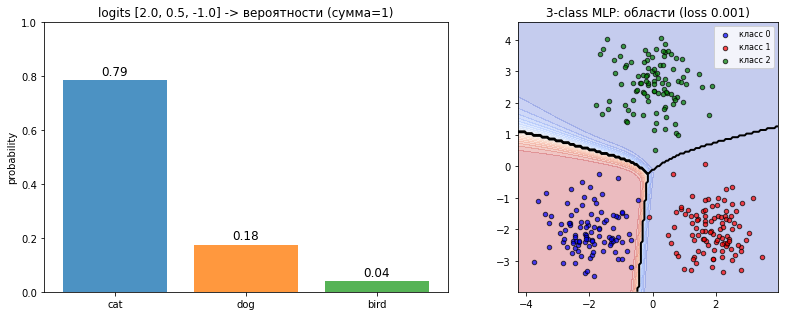

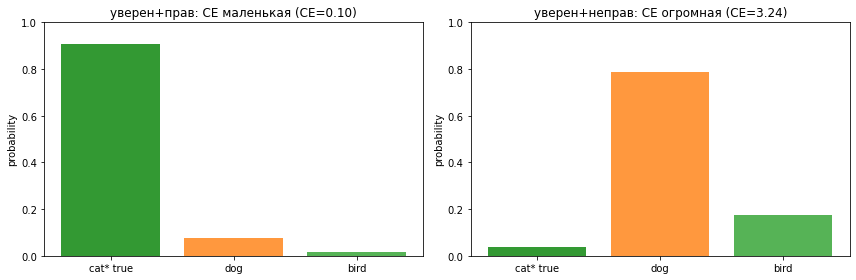

softmax от [2.0, 0.5, -1.0]: [0.786 0.175 0.039] | CE loss если true class = 0: 0.241


In [18]:
# FIGURE: softmax bars for one example + MLP decision regions for 3 classes.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
logits = np.array([[2.0, 0.5, -1.0]])
probs = softmax(logits).ravel()
ax.bar(['cat', 'dog', 'bird'], probs, color=['tab:blue', 'tab:orange', 'tab:green'], alpha=0.8)
for i, v in enumerate(probs):
    ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=12)
ax.set_ylim(0, 1); ax.set_title('logits [2.0, 0.5, -1.0] -> вероятности (сумма=1)')
ax.set_ylabel('probability')

# tiny 2-10-3 MLP, softmax + cross-entropy, full-batch GD
def train_ce_mlp(X, y, H=10, lr=0.5, iters=2500, seed=3):
    r = np.random.default_rng(seed)
    N, K = X.shape[0], int(y.max()) + 1
    Y = np.eye(K)[y]
    W1 = r.normal(0, 1, size=(2, H)) * np.sqrt(1 / 2); b1 = np.zeros(H)
    W2 = r.normal(0, 1, size=(H, K)) * np.sqrt(1 / H); b2 = np.zeros(K)
    hist = []
    for _ in range(iters):
        A1 = tanh(X @ W1 + b1)
        P = softmax(A1 @ W2 + b2)
        hist.append(-np.mean(np.log(P[np.arange(N), y] + 1e-9)))
        dZ2 = (P - Y) / N
        dW2 = A1.T @ dZ2; db2 = dZ2.sum(axis=0)
        dZ1 = (dZ2 @ W2.T) * (1 - A1 ** 2)
        dW1 = X.T @ dZ1; db1 = dZ1.sum(axis=0)
        W2 -= lr * dW2; b2 -= lr * db2; W1 -= lr * dW1; b1 -= lr * db1
    return (W1, b1, W2, b2), np.array(hist)

params3, hist3 = train_ce_mlp(X_3, y_3)
ax = axes[1]
x1 = np.linspace(X_3[:, 0].min() - 0.5, X_3[:, 0].max() + 0.5, 150)
x2 = np.linspace(X_3[:, 1].min() - 0.5, X_3[:, 1].max() + 0.5, 150)
G1, G2 = np.meshgrid(x1, x2)
W1, b1, W2, b2 = params3
P = softmax(tanh(np.c_[G1.ravel(), G2.ravel()] @ W1 + b1) @ W2 + b2)
ax.contourf(G1, G2, P[:, 0].reshape(G1.shape), levels=20, cmap='coolwarm', alpha=0.3)
ax.contour(G1, G2, P.argmax(axis=1).reshape(G1.shape), levels=[0.5, 1.5], colors='k', linewidths=2)
for k, c in zip([0, 1, 2], ['blue', 'red', 'green']):
    ax.scatter(X_3[y_3 == k, 0], X_3[y_3 == k, 1], c=c, edgecolors='k', s=20, alpha=0.7, label=f'класс {k}')
ax.set_title(f'3-class MLP: области (loss {hist3[-1]:.3f})')
ax.legend(fontsize=8); ax.set_aspect('equal', adjustable='box')
plt.tight_layout(); plt.show()
# FIGURE-2: same true class, confident-right vs confident-wrong.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, lg, t in zip(axes, [[3.0, 0.5, -1.0], [-1.0, 2.0, 0.5]], ['уверен+прав: CE маленькая', 'уверен+неправ: CE огромная']):
    pr = softmax(np.array([lg])).ravel()
    ax.bar(['cat* true', 'dog', 'bird'], pr, color=['green', 'tab:orange', 'tab:green'], alpha=0.8)
    ax.set_ylim(0, 1)
    ax.set_title(f'{t} (CE={-np.log(pr[0]):.2f})')
    ax.set_ylabel('probability')
plt.tight_layout(); plt.show()
print('softmax от [2.0, 0.5, -1.0]:', np.round(probs, 3), '| CE loss если true class = 0:', round(-np.log(probs[0]), 3))

### Производная softmax + CE: тот же $p - y$

Softmax: $p_k = e^{z_k}/S$, $S = \sum_j e^{z_j}$. Сначала якобиан — как $p_k$ зависит от $z_j$ (quotient rule, два случая):
- $k = j$: $\frac{\partial p_k}{\partial z_k} = \frac{e^{z_k}S - e^{z_k}e^{z_k}}{S^2} = p_k(1-p_k)$;
- $k \ne j$: $\frac{\partial p_k}{\partial z_j} = \frac{0 - e^{z_k}e^{z_j}}{S^2} = -p_k p_j$.

Вместе: $\frac{\partial p_k}{\partial z_j} = p_k(\delta_{kj} - p_j)$ ($\delta$ — 1 если $k=j$, иначе 0).
Диагональ положительна (свой логит тянет свою вероятность вверх), всё остальное отрицательно (чужие логиты давят вниз).

CE loss: $J = -\sum_k y_k \log p_k$ (one-hot $y$). Chain rule суммирует по всем $k$:
$$\frac{dJ}{dz_j} = -\sum_k y_k \frac{1}{p_k}\, p_k(\delta_{kj}-p_j) = -\sum_k y_k(\delta_{kj}-p_j) = -(y_j - p_j\underbrace{\sum_k y_k}_{=1}) = p_j - y_j.$$

Та же формула! Sigmoid + BCE — её частный случай при $K=2$. Ниже: якобиан числом + heatmap + проверка градиента.

analytic Jacobian:
 [[ 0.1684 -0.1377 -0.0307]
 [-0.1377  0.1446 -0.0069]
 [-0.0307 -0.0069  0.0376]]
max |analytic - numeric|: 4.2402675815012003e-10
dJ/dz analytic (p-y): [-0.2144  0.1753  0.0391] | numeric: [-0.2144  0.1753  0.0391]


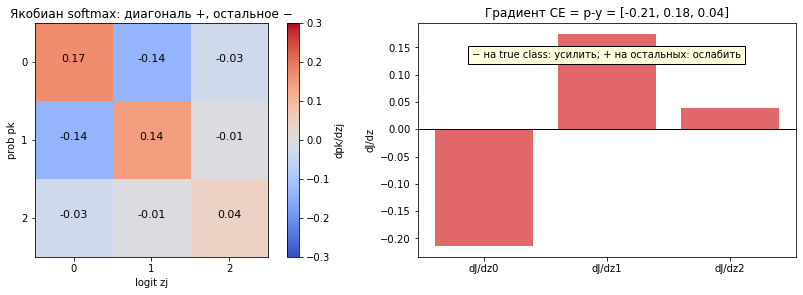

In [19]:
# FIGURE+PROOF: softmax Jacobian analytic vs numeric (heatmap) + CE gradient check.
z = np.array([2.0, 0.5, -1.0]); y = np.array([1, 0, 0])  # true = class 0
p = softmax(z.reshape(1, -1)).ravel()
K = 3
Jac = np.array([[p[k] * ((k == j) - p[j]) for j in range(K)] for k in range(K)])
e = 1e-7
Jnum = np.zeros((K, K))
for k in range(K):
    for j in range(K):
        zp, zm = z.copy(), z.copy(); zp[j] += e; zm[j] -= e
        pp = softmax(zp.reshape(1, -1)).ravel(); pm = softmax(zm.reshape(1, -1)).ravel()
        Jnum[k, j] = (pp[k] - pm[k]) / (2 * e)
print('analytic Jacobian:\n', np.round(Jac, 4))
print('max |analytic - numeric|:', np.max(np.abs(Jac - Jnum)))
assert np.allclose(Jac, Jnum, atol=1e-6)
dJ_dz = p - y
def ce(zz):
    pp = softmax(zz.reshape(1, -1)).ravel()
    return -np.sum(y * np.log(pp + 1e-12))
num_g = np.array([(ce(z + (np.arange(K) == j) * e) - ce(z - (np.arange(K) == j) * e)) / (2 * e) for j in range(K)])
print('dJ/dz analytic (p-y):', np.round(dJ_dz, 4), '| numeric:', np.round(num_g, 4))
assert np.allclose(dJ_dz, num_g, atol=1e-6)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
im = ax.imshow(Jac, cmap='coolwarm', vmin=-0.3, vmax=0.3)
for k in range(K):
    for j in range(K):
        ax.text(j, k, f'{Jac[k, j]:.2f}', ha='center', fontsize=11)
ax.set_xticks(range(K)); ax.set_yticks(range(K))
ax.set_xlabel('logit zj'); ax.set_ylabel('prob pk')
ax.set_title('Якобиан softmax: диагональ +, остальное −')
plt.colorbar(im, ax=ax, label='dpk/dzj')
ax = axes[1]
ax.bar(['dJ/dz0', 'dJ/dz1', 'dJ/dz2'], dJ_dz, color='tab:red', alpha=0.7)
ax.axhline(0, color='k', lw=1)
ax.set_title(f'Градиент CE = p-y = {list(np.round(dJ_dz, 2))}')
ax.set_ylabel('dJ/dz')
ax.text(0.5, 0.85, '− на true class: усилить; + на остальных: ослабить', ha='center', transform=ax.transAxes,
        bbox=dict(fc='lightyellow', ec='k'))
plt.tight_layout(); plt.show()

## 8. Chain rule для производных

Backprop — это одно правило, применённое много раз. Если $y$ зависит от $u$, а $u$ от $x$:

$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

Аналогия с шестерёнками: ручка $x$ крутит шестерню $u$, та крутит $y$ — общее передаточное число = произведение.
Пример: $u = 2x + 1$, $y = u^2$. Тогда $dy/du = 2u$, $du/dx = 2$, и
$dy/dx = 2u \cdot 2 = 4u = 4(2x+1)$. В точке $x = 1$: аналитика $12$, numeric check ниже.
Каждый layer MLP — ещё одна шестерёнка: просто умножаем вдоль цепочки.

x=1: u=3.0, dy/du=6.0, du/dx=2.0 -> dy/dx=12.0 | numeric=12.000000 | match=True


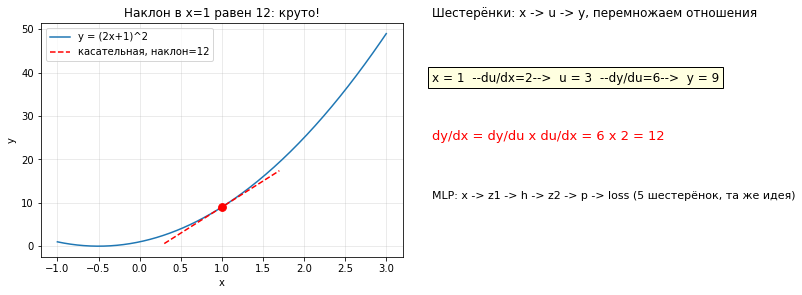

In [20]:
# FIGURE: chain rule = multiply local slopes along the path; numeric check included.
x0 = 1.0
u0 = 2 * x0 + 1
dy_du = 2 * u0; du_dx = 2.0
dy_dx = dy_du * du_dx
e = 1e-6
num = ((2 * (x0 + e) + 1) ** 2 - (2 * (x0 - e) + 1) ** 2) / (2 * e)
print(f'x=1: u={u0}, dy/du={dy_du}, du/dx={du_dx} -> dy/dx={dy_dx} | numeric={num:.6f} | match={np.isclose(dy_dx, num)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]
xs = np.linspace(-1, 3, 200)
ax.plot(xs, (2 * xs + 1) ** 2, label='y = (2x+1)^2')
ax.scatter([x0], [(2 * x0 + 1) ** 2], c='r', s=60, zorder=5)
t = np.linspace(x0 - 0.7, x0 + 0.7, 50)
ax.plot(t, (2 * x0 + 1) ** 2 + dy_dx * (t - x0), 'r--', label=f'касательная, наклон={dy_dx:.0f}')
ax.set_title('Наклон в x=1 равен 12: круто!'); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax = axes[1]; ax.axis('off')
ax.set_title('Шестерёнки: x -> u -> y, перемножаем отношения')
ax.text(0.05, 0.75, 'x = 1  --du/dx=2-->  u = 3  --dy/du=6-->  y = 9', fontsize=12,
        bbox=dict(fc='lightyellow', ec='k'), transform=ax.transAxes)
ax.text(0.05, 0.50, 'dy/dx = dy/du x du/dx = 6 x 2 = 12', fontsize=13, color='red', transform=ax.transAxes)
ax.text(0.05, 0.25, 'MLP: x -> z1 -> h -> z2 -> p -> loss (5 шестерёнок, та же идея)', fontsize=11, transform=ax.transAxes)
plt.tight_layout(); plt.show()

## 9. Backpropagation на 2 входах (скаляры, по шагам)

Крошечная сеть: $x_1, x_2 \to h_1, h_2$ (sigmoid) $\to$ выход $o$ (sigmoid) $\to$ BCE loss.
Forward pass считает значения; backward pass идёт **назад**, умножая на каждый локальный наклон:

$$\delta_o = o - y, \quad \delta_{h1} = \delta_o v_1 \cdot h_1(1-h_1), \quad
\frac{\partial J}{\partial v_1} = \delta_o h_1, \quad
\frac{\partial J}{\partial w_{11}} = \delta_{h1} x_1 \;\; \text{(и т.д.)}$$

Трюк с сигмоидой $d\sigma/dz = \sigma(1-\sigma)$ — единственный факт из анализа (а почему цепочка в конце даёт просто $o - y$ — доказано в разделе 6).
Код печатает каждый шаг; столбцы показывают, кто учится быстрее; numeric check доказывает алгебру.

вперёд: z1=0.620 h1=0.650 | z2=-0.760 h2=0.319 | z3=0.296 o=0.573 | loss=0.556
назад: do=-0.427 | dv1=-0.277 dv2=-0.136
       dz1=-0.068 dz2=0.046
       dw11=-0.054 dw12=0.027 dw21=0.037 dw22=-0.019
проверка dw11: аналитика -0.054330 vs численно -0.054330 -> True
проверка dw21: аналитика 0.037046 vs численно 0.037046 -> True


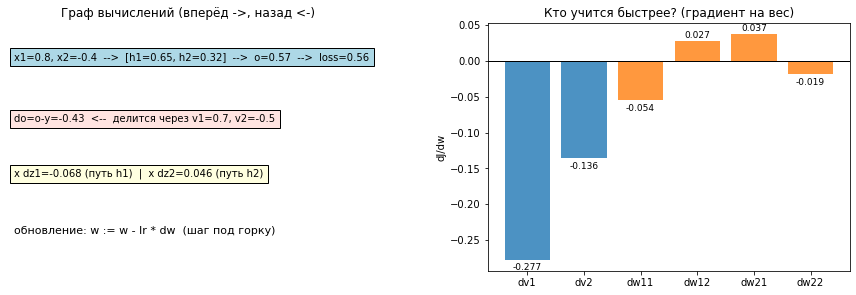

In [21]:
# WORKED EXAMPLE: forward with plain numbers, backward with the chain rule, numeric check.
x1, x2, y = 0.8, -0.4, 1
w11, w12, b1 = 0.5, -0.3, 0.1
w21, w22, b2 = -0.4, 0.6, -0.2
v1, v2, c = 0.7, -0.5, 0.0

# forward
z1 = w11 * x1 + w12 * x2 + b1; h1 = sigmoid(z1)
z2 = w21 * x1 + w22 * x2 + b2; h2 = sigmoid(z2)
z3 = v1 * h1 + v2 * h2 + c; o = sigmoid(z3)
J = -(y * np.log(o) + (1 - y) * np.log(1 - o))
print(f'вперёд: z1={z1:.3f} h1={h1:.3f} | z2={z2:.3f} h2={h2:.3f} | z3={z3:.3f} o={o:.3f} | loss={J:.3f}')

# backward (chain rule, reverse order)
do = o - y                       # dJ/dz3 for sigmoid + BCE: simply (o - y)!
dv1, dv2, dc = do * h1, do * h2, do
dh1, dh2 = do * v1, do * v2       # through the output weights
dz1 = dh1 * h1 * (1 - h1)         # through sigmoid: sigma*(1-sigma)
dz2 = dh2 * h2 * (1 - h2)
dw11, dw12, db1 = dz1 * x1, dz1 * x2, dz1
dw21, dw22, db2 = dz2 * x1, dz2 * x2, dz2
print(f'назад: do={do:.3f} | dv1={dv1:.3f} dv2={dv2:.3f}')
print(f'       dz1={dz1:.3f} dz2={dz2:.3f}')
print(f'       dw11={dw11:.3f} dw12={dw12:.3f} dw21={dw21:.3f} dw22={dw22:.3f}')

# numeric check of two gradients
def loss_fn(w11_, w21_):
    h1_ = sigmoid(w11_ * x1 + w12 * x2 + b1); h2_ = sigmoid(w21_ * x1 + w22 * x2 + b2)
    o_ = sigmoid(v1 * h1_ + v2 * h2_ + c)
    return -(y * np.log(o_) + (1 - y) * np.log(1 - o_))
e = 1e-6
n11 = (loss_fn(w11 + e, w21) - loss_fn(w11 - e, w21)) / (2 * e)
n21 = (loss_fn(w11, w21 + e) - loss_fn(w11, w21 - e)) / (2 * e)
print(f'проверка dw11: аналитика {dw11:.6f} vs численно {n11:.6f} -> {np.isclose(dw11, n11)}')
print(f'проверка dw21: аналитика {dw21:.6f} vs численно {n21:.6f} -> {np.isclose(dw21, n21)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ax = axes[0]; ax.axis('off')
ax.set_title('Граф вычислений (вперёд ->, назад <-)')
ax.text(0.02, 0.85, 'x1=0.8, x2=-0.4  -->  [h1=0.65, h2=0.32]  -->  o=0.57  -->  loss=0.56', fontsize=10,
        bbox=dict(fc='lightblue', ec='k'), transform=ax.transAxes)
ax.text(0.02, 0.60, f'do=o-y={do:.2f}  <--  делится через v1={v1}, v2={v2}', fontsize=10,
        bbox=dict(fc='mistyrose', ec='k'), transform=ax.transAxes)
ax.text(0.02, 0.38, f'x dz1={dz1:.3f} (путь h1)  |  x dz2={dz2:.3f} (путь h2)', fontsize=10,
        bbox=dict(fc='lightyellow', ec='k'), transform=ax.transAxes)
ax.text(0.02, 0.15, 'обновление: w := w - lr * dw  (шаг под горку)', fontsize=11, transform=ax.transAxes)
ax = axes[1]
labels = ['dv1', 'dv2', 'dw11', 'dw12', 'dw21', 'dw22']
vals = [dv1, dv2, dw11, dw12, dw21, dw22]
ax.bar(labels, vals, color=['tab:blue'] * 2 + ['tab:orange'] * 4, alpha=0.8)
ax.axhline(0, color='k', lw=1)
ax.set_title('Кто учится быстрее? (градиент на вес)')
ax.set_ylabel('dJ/dw')
for i, v in enumerate(vals):
    ax.text(i, v + (0.005 if v > 0 else -0.015), f'{v:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

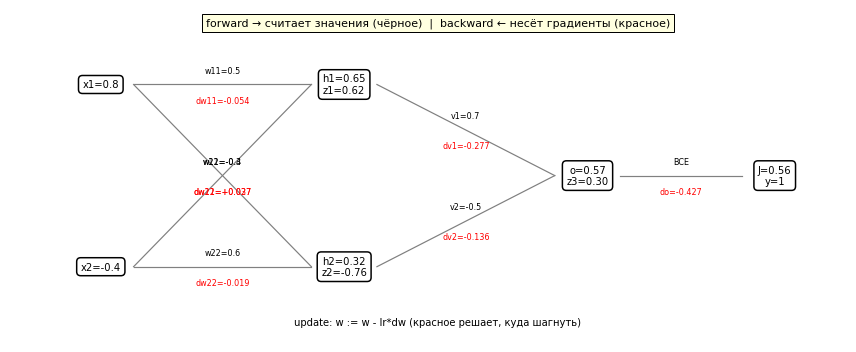

In [22]:
# FIGURE: full forward/backward map of the section-9 net (black = values, red = gradients).
fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('off'); ax.set_xlim(-1, 8); ax.set_ylim(-2.6, 2.6)
nodes = {'x1': (0, 1.4, 'x1=0.8'), 'x2': (0, -1.4, 'x2=-0.4'),
         'h1': (2.6, 1.4, 'h1=0.65\nz1=0.62'), 'h2': (2.6, -1.4, 'h2=0.32\nz2=-0.76'),
         'o': (5.2, 0, 'o=0.57\nz3=0.30'), 'J': (7.2, 0, 'J=0.56\ny=1')}
for k, (x, y, t) in nodes.items():
    ax.text(x, y, t, ha='center', va='center', fontsize=10,
            bbox=dict(fc='white', ec='k', lw=1.5, boxstyle='round,pad=0.4'))
edges = [(('x1', 'h1'), 'w11=0.5', 'dw11=-0.054'), (('x2', 'h1'), 'w12=-0.3', 'dw12=+0.027'),
         (('x1', 'h2'), 'w21=-0.4', 'dw21=+0.037'), (('x2', 'h2'), 'w22=0.6', 'dw22=-0.019'),
         (('h1', 'o'), 'v1=0.7', 'dv1=-0.277'), (('h2', 'o'), 'v2=-0.5', 'dv2=-0.136'),
         (('o', 'J'), 'BCE', 'do=-0.427')]
for (a, b), fw, bw in edges:
    x0, y0, _ = nodes[a]; x1, y1, _ = nodes[b]
    ax.plot([x0 + 0.35, x1 - 0.35], [y0, y1], color='0.5', lw=1.2)
    mx, my = (x0 + x1) / 2, (y0 + y1) / 2
    ax.text(mx, my + 0.18, fw, ha='center', fontsize=8)
    ax.text(mx, my - 0.28, bw, ha='center', fontsize=8, color='red')
ax.text(3.6, 2.3, 'forward → считает значения (чёрное)  |  backward ← несёт градиенты (красное)', ha='center', fontsize=11,
        bbox=dict(fc='lightyellow', ec='k'))
ax.text(3.6, -2.3, 'update: w := w - lr*dw (красное решает, куда шагнуть)', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

## 10. Backpropagation в матрицах

Скаляры становятся матрицами — та же математика, без сумм. Для $Z = XW + b$, $A = \phi(Z)$ и ошибки, идущей назад:

$$dW = X^T dZ, \qquad db = \sum_{rows} dZ, \qquad dX = dZ\, W^T$$

**Shape rule** (единственное, что надо запомнить): $dW$ той же формы, что $W$.
Проверка: $X^T$ это $d \times N$, $dZ$ это $N \times H$ $\to$ $d \times H$ = форма $W$. ✓

**Шпаргалка backward — по одной формуле на слой:**

- linear $Z = XW + b$: $dW = X^T dZ / n$, $db = mean(dZ)$, дальше назад $dX = dZ W^T$;
- activation $A = \tanh(Z)$: $dZ = dA \cdot (1 - A^2)$;
- activation $A = ReLU(Z)$: $dZ = dA \cdot (Z > 0)$;
- output $P = sigmoid(Z)$ + BCE loss: $dZ = (P - y) / n$;
- output $P = softmax(Z)$ + CE loss: $dZ = (P - Y) / n$.

Одна матричная строка заменяет все скалярные — и крутится в быстрых C-циклах. Ниже: как формы текут по сети; код доказывает matrix == scalar, потом учит настоящую сеть.

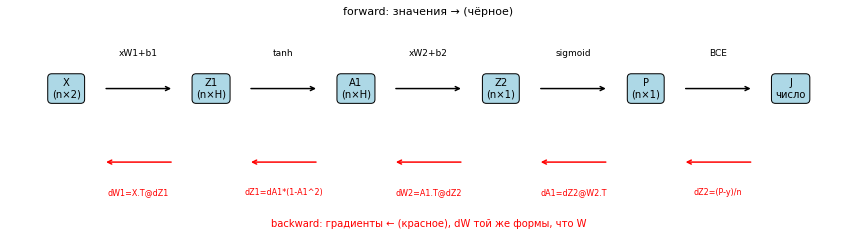

In [23]:
# FIGURE: shapes flowing forward (black) and backward (red) through a 2-H-1 net.
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 3)
boxes = ['X\n(n×2)', 'Z1\n(n×H)', 'A1\n(n×H)', 'Z2\n(n×1)', 'P\n(n×1)', 'J\nчисло']
ops = ['xW1+b1', 'tanh', 'xW2+b2', 'sigmoid', 'BCE']
bwd = ['dW1=X.T@dZ1', 'dZ1=dA1*(1-A1^2)', 'dW2=A1.T@dZ2', 'dA1=dZ2@W2.T', 'dZ2=(P-y)/n']
xs = np.linspace(0.7, 9.3, 6)
for x, b in zip(xs, boxes):
    ax.text(x, 1.9, b, ha='center', va='center', fontsize=10,
            bbox=dict(fc='lightblue', ec='k', boxstyle='round,pad=0.4'))
for i, op in enumerate(ops):
    ax.annotate('', xy=(xs[i+1] - 0.45, 1.9), xytext=(xs[i] + 0.45, 1.9),
                arrowprops=dict(arrowstyle='->', color='k', lw=1.5))
    ax.text((xs[i] + xs[i+1]) / 2, 2.35, op, ha='center', fontsize=9)
for i in range(5):
    ax.annotate('', xy=(xs[i] + 0.45, 0.9), xytext=(xs[i+1] - 0.45, 0.9),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    ax.text((xs[i] + xs[i+1]) / 2, 0.45, bwd[i], ha='center', fontsize=8, color='red')
ax.text(5, 2.9, 'forward: значения → (чёрное)', ha='center', fontsize=11)
ax.text(5, 0.02, 'backward: градиенты ← (красное), dW той же формы, что W', ha='center', fontsize=10, color='red')
plt.tight_layout(); plt.show()

matrix dW1 (строки=x1,x2 столбцы=h1,h2): [-0.05433   0.037046  0.027165 -0.018523]
scalar [dw11, dw12, dw21, dw22]:         [-0.05433   0.027165  0.037046 -0.018523]
matrix dW2: [-0.277368 -0.135927] | scalar [dv1, dv2]: [-0.277368 -0.135927]
совпало: matrix == scalar (те же числа, упакованы в массивы)
shapes: X (1, 2) W1 (2, 2) dW1 (2, 2) | W2 (2, 1) dW2 (2, 1)


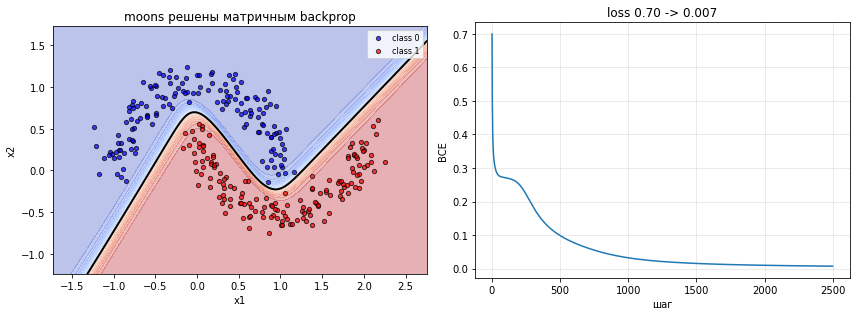

In [24]:
# PROOF: matrix backprop gives exactly the scalar gradients from section 9 (batch of 1).
X = np.array([[0.8, -0.4]]); Y = np.array([[1]])
W1m = np.array([[0.5, -0.4], [-0.3, 0.6]]); b1m = np.array([0.1, -0.2])
W2m = np.array([[0.7], [-0.5]]); b2m = np.array([0.0])
Z1 = X @ W1m + b1m; A1 = sigmoid(Z1)
Z2 = A1 @ W2m + b2m; A2 = sigmoid(Z2)
dZ2 = (A2 - Y) / 1; dW2 = A1.T @ dZ2; db2 = dZ2.sum(axis=0)
dA1 = dZ2 @ W2m.T; dZ1 = dA1 * A1 * (1 - A1)
dW1 = X.T @ dZ1; db1 = dZ1.sum(axis=0)
print('matrix dW1 (строки=x1,x2 столбцы=h1,h2):', np.round(dW1.ravel(), 6))
print('scalar [dw11, dw12, dw21, dw22]:        ', np.round([dw11, dw12, dw21, dw22], 6))
print('matrix dW2:', np.round(dW2.ravel(), 6), '| scalar [dv1, dv2]:', np.round([dv1, dv2], 6))
assert np.allclose(dW1[0, 0], dw11) and np.allclose(dW1[1, 0], dw12)
assert np.allclose(dW1[0, 1], dw21) and np.allclose(dW1[1, 1], dw22)
assert np.allclose(dW2.ravel(), [dv1, dv2])
print('совпало: matrix == scalar (те же числа, упакованы в массивы)')

# shapes: dW has the shape of W
print('shapes: X', X.shape, 'W1', W1m.shape, 'dW1', dW1.shape, '| W2', W2m.shape, 'dW2', dW2.shape)

# full training with the matrix form on moons: loss + final boundary
params_m, hist_m = train_bce_mlp(X_moon, y_moon, H=8, lr=0.5, iters=2500, seed=5)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_boundary(axes[0], X_moon, y_moon, lambda G: mlp_prob(G, params_m), title='moons решены матричным backprop')
axes[0].set_xlabel('x1'); axes[0].set_ylabel('x2')
axes[1].plot(hist_m)
axes[1].set_title(f'loss {hist_m[0]:.2f} -> {hist_m[-1]:.3f}'); axes[1].set_xlabel('шаг'); axes[1].set_ylabel('BCE')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Выводы

1. Один нейрон = одна линия; для XOR/moons/circles этого мало. 2. Hidden layers переписывают пространство, и последней линии хватает.
3. Без activation слои схлопываются в одну линию; activations изгибают. 4–5. Голосование линий / сложение hinges приближает любую границу или кривую (больше нейронов = больше деталей).
6. Бинарный loss = negative log-likelihood (BCE); у MSE здесь умирают градиенты; градиент BCE: $dJ/dz = p - y$ (вывод внутри).
7. Multiclass: softmax + cross-entropy = $-\log$ вероятности true class; градиент тот же: $p - y$ (вывод внутри, якобиан softmax — тоже).
8–10. Backprop = chain rule наоборот; скалярные передаточные числа упаковываются в $dW = X^T dZ$.

Поиграться: [TensorFlow Playground](https://playground.tensorflow.org) — соберите сети 2-4-1 на circle/spiral и смотрите, как гнутся границы, вживую.